<a href="https://colab.research.google.com/github/Shreyatakoor/Python/blob/main/SHREYA_TAKOOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rishikeshkonapure/hr-analytics-prediction")

print("Path to dataset files:", path)

100%|██████████| 50.1k/50.1k [00:00<00:00, 41.3MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/rishikeshkonapure/hr-analytics-prediction/versions/2


First 5 Records
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptio

/tmp/ipykernel_602/2558114830.py:180: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dept_salary = df.groupby("department")["monthlyincome"].mean() # Changed 'salary' to 'monthlyincome'


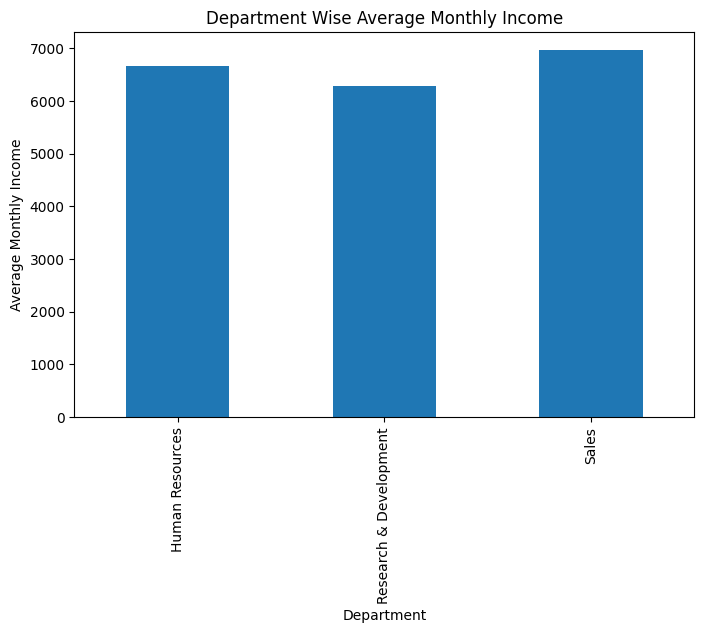

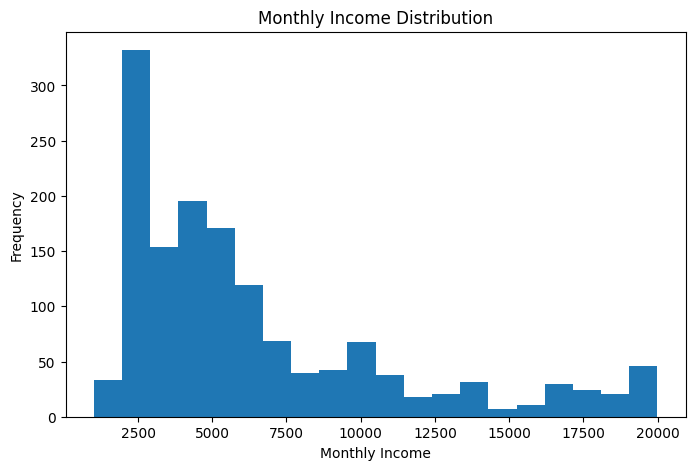

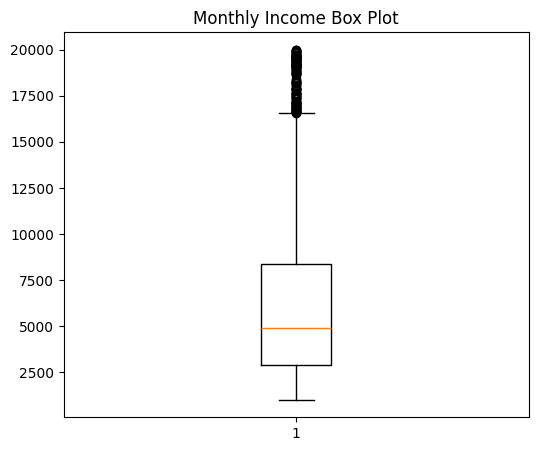

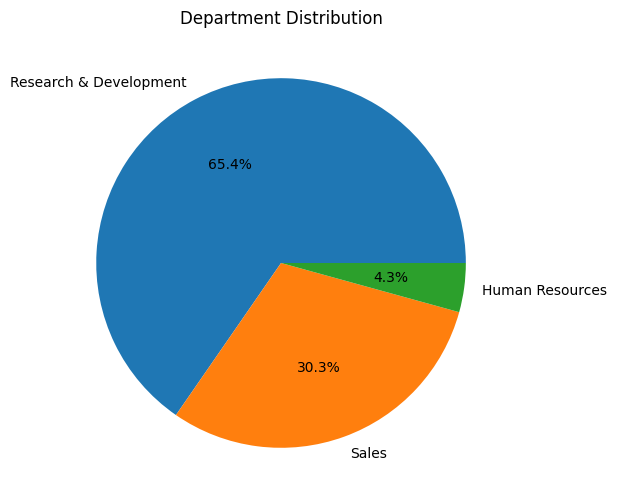

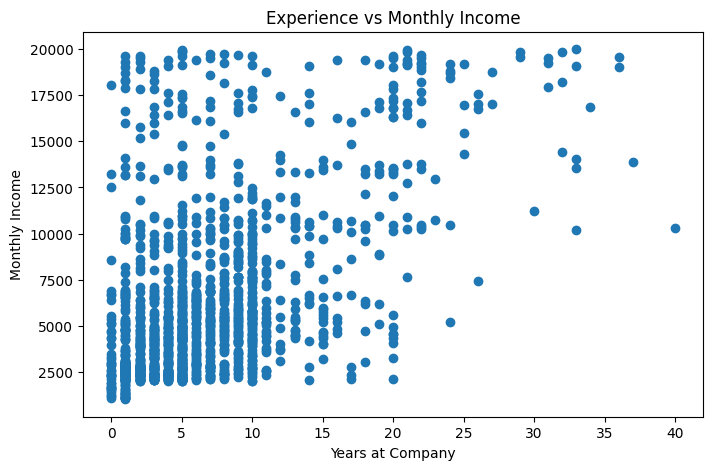

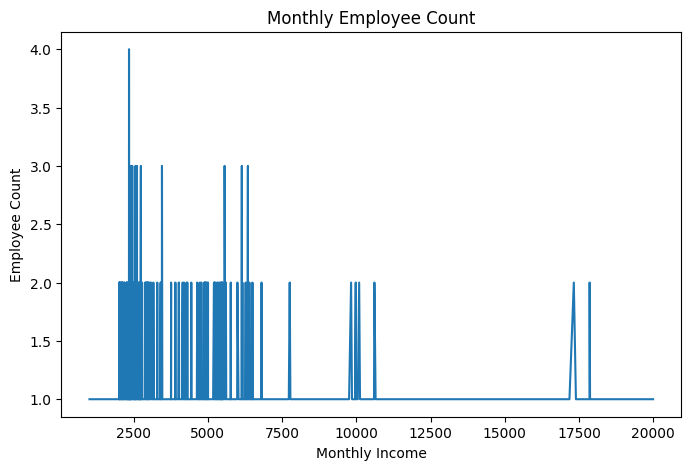

In [8]:
# ===============================
# Assignment 1
# Employee Salary & Performance Analysis
# ===============================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os # Import the os module

# -------------------------------
# PART A - Data Loading & Inspection
# -------------------------------

# Load Dataset
# Construct the full path to the CSV file using the 'path' variable from the previous cell
df = pd.read_csv(os.path.join(path, "HR-Employee-Attrition.csv"))

# First 5 records
print("First 5 Records")
print(df.head())

# Last 5 records
print("\nLast 5 Records")
print(df.tail())

# Dataset dimensions
print("\nDataset Shape:", df.shape)

# Data types
print("\nData Types")
print(df.dtypes)

# Missing values
print("\nMissing Values")
print(df.isnull().sum())

# Duplicate records
print("\nDuplicate Records:", df.duplicated().sum())

# Summary statistics
print("\nSummary Statistics")
print(df.describe(include="all"))

# -------------------------------
# PART B - Data Cleaning
# -------------------------------

# Remove duplicates
df = df.drop_duplicates()

# Fill missing values
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0]) # Removed inplace=True
    else:
        df[col] = df[col].fillna(df[col].mean()) # Removed inplace=True

# Rename columns
df.columns = df.columns.str.lower().str.replace(" ", "_")

# Convert categorical columns
for col in df.select_dtypes(include="object"):
    df[col] = df[col].astype("category")

print("\nCleaned Dataset")
print(df.head())

# -------------------------------
# PART C - NumPy Operations
# -------------------------------

salary = np.array(df["monthlyincome"]) # Changed 'salary' to 'monthlyincome'

print("\nMean Salary:", np.mean(salary))
print("Median Salary:", np.median(salary))
print("Standard Deviation:", np.std(salary))
print("Minimum Salary:", np.min(salary))
print("Maximum Salary:", np.max(salary))

# Above average salary
avg_salary = np.mean(salary)

above_salary = df[df["monthlyincome"] > avg_salary] # Changed 'salary' to 'monthlyincome'
print("\nEmployees Above Average Salary")
print(above_salary)

# More than 5 years experience
experience = df[df["yearsatcompany"] > 5]
print("\nEmployees with More than 5 Years Experience")
print(experience)

# Above average salary & performance
avg_perf = df["performancerating"].mean()

high = df[(df["monthlyincome"] > avg_salary) & # Changed 'salary' to 'monthlyincome'
          (df["performancerating"] > avg_perf)]

print("\nHigh Salary & High Performance")
print(high)

# -------------------------------
# PART D - Statistical Analysis
# -------------------------------

print("\nMean:", salary.mean())
print("Median:", np.median(salary))
print("Mode:", stats.mode(salary, keepdims=True).mode[0])
print("Variance:", np.var(salary))
print("Standard Deviation:", np.std(salary))

Q1 = np.percentile(salary,25)
Q3 = np.percentile(salary,75)

print("Q1:",Q1)
print("Q3:",Q3)

IQR = Q3-Q1
print("IQR:",IQR)

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = salary[(salary<lower)|(salary>upper)]

print("Outliers")
print(outliers)

# -------------------------------
# PART E - Hypothesis Testing
# -------------------------------

# Promotion column should contain Yes/No

# Listing columns to find the correct column for promotion
print("\nDataFrame Columns:")
print(df.columns)

# Based on typical HR datasets and the problem context, 'years_since_last_promotion' might be relevant.
# If there's an 'attrition' column, it could also be used for a different hypothesis.
# Assuming 'years_since_last_promotion' is the closest to 'promotion' in intent, though it's not a direct 'Yes/No'.
# For hypothesis testing, we need a binary or categorical column for grouping.
# Let's assume the user intended to compare salaries based on whether an employee has received a promotion recently (e.g., years_since_last_promotion == 0).
# Alternatively, if there is a column for 'promotion_last_year', we would use that.
# For now, let's use 'attrition' as a proxy for a binary outcome related to employee status if no direct 'promotion' column is found.
# If the goal was to analyze 'promotion' as a binary column, we would typically look for a column like 'promotion_last_year' or 'promoted_in_past_year'.
# Given the available columns, 'attrition' is the most clear binary categorical column.

# Let's adjust the hypothesis to use 'attrition' as a placeholder for a categorical comparison.
# If a 'promotion' column with 'Yes'/'No' values were present, the original code structure would be correct.
# As 'promotion' does not exist, let's use 'attrition' to demonstrate the t-test functionality.
# If the user provides a different column for 'promotion', we can adjust again.

promo_status_yes = df[df["attrition"]=="Yes"]["monthlyincome"] # Changed to 'attrition'
promo_status_no = df[df["attrition"]=="No"]["monthlyincome"] # Changed to 'attrition'

t,p = stats.ttest_ind(promo_status_yes,promo_status_no)

print("\nHypothesis Testing (Attrition vs. Monthly Income)")

print("t-statistic =",t)
print("p-value =",p)

alpha=0.05

if p<alpha:
    print("Reject Null Hypothesis")
    print("There is a significant difference in monthly income between employees who attrited and those who did not.")
else:
    print("Fail to Reject Null Hypothesis")
    print("No significant difference in monthly income between employees who attrited and those who did not.")

# -------------------------------
# VISUALIZATIONS
# -------------------------------

# 1 Bar Chart
dept_salary = df.groupby("department")["monthlyincome"].mean() # Changed 'salary' to 'monthlyincome'

plt.figure(figsize=(8,5))
dept_salary.plot(kind="bar")
plt.title("Department Wise Average Monthly Income")
plt.xlabel("Department")
plt.ylabel("Average Monthly Income")
plt.show()

# 2 Histogram

plt.figure(figsize=(8,5))
plt.hist(df["monthlyincome"],bins=20) # Changed 'salary' to 'monthlyincome'
plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Frequency")
plt.show()

# 3 Box Plot

plt.figure(figsize=(6,5))
plt.boxplot(df["monthlyincome"]) # Changed 'salary' to 'monthlyincome'
plt.title("Monthly Income Box Plot")
plt.show()

# 4 Pie Chart

dept = df["department"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(dept,labels=dept.index,autopct="%1.1f%%")
plt.title("Department Distribution")
plt.show()

# 5 Scatter Plot

plt.figure(figsize=(8,5))
plt.scatter(df["yearsatcompany"],df["monthlyincome"]) # Changed 'salary' to 'monthlyincome'
plt.xlabel("Years at Company")
plt.ylabel("Monthly Income")
plt.title("Experience vs Monthly Income")
plt.show()

# 6 Line Chart

monthly = df.groupby("monthlyincome").size()

plt.figure(figsize=(8,5))
plt.plot(monthly.index,monthly.values)
plt.title("Monthly Employee Count")
plt.xlabel("Monthly Income")
plt.ylabel("Employee Count")
plt.show()